# Source Exploration

Profile each source in MENTION to understand field coverage, temporal range,
and name quality — inputs needed to design the record linkage blocking and
comparison strategy.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 40)

## Load Data

In [2]:
MENTION = pd.read_parquet('../data/MENTION.parquet')
print(MENTION.shape)
MENTION.head(3)

(86825, 26)


,source,source_year,confidence,full_name,first_name,middle_name,last_name,maiden_name,birth_year,death_year,race,gender,occupation,legal_status,is_enslaver,norm_first_name,nysiis_last_name,norm_race,norm_occupation,enslaver_id,location_id,head,household_id,family_id,narrative,person_key
mention_id,,,,,,,,,,,,,,,,,,,,,,,,,,
a632802a-a920-4a60-b231-504c103e1bbe,ALB_SS-1860,1860,0.82,NaN,NaN,NaN,NaN,NaN,1824,NaN,B,M,NaN,E,f,NaN,NaN,B,NaN,NaN,NaN,f,NaN,NaN,NaN,1824-b-m-x
e4cf1dc7-dc28-478f-989c-8d1be7c0f33b,ALB_SS-1860,1860,0.82,NaN,NaN,NaN,NaN,NaN,1826,NaN,B,M,NaN,E,f,NaN,NaN,B,NaN,NaN,NaN,f,NaN,NaN,NaN,1826-b-m-x
e0153e40-ebba-4de8-bd4c-9cb8298668bd,ALB_SS-1860,1860,0.82,NaN,NaN,NaN,NaN,NaN,1808,NaN,M,F,NaN,E,f,NaN,NaN,B,NaN,NaN,NaN,f,NaN,NaN,NaN,1808-b-f-x


## Clean String Columns

Values imported from PostgreSQL CSV may have residual quoting artifacts (`'value',`).
Strip leading/trailing quotes and commas.

In [3]:
def clean_val(s):
    if pd.isna(s):
        return s
    s = str(s).strip().strip("'").rstrip(',')
    return None if s in ('NULL', '') else s

str_cols = MENTION.select_dtypes('object').columns.tolist()
MENTION[str_cols] = MENTION[str_cols].apply(lambda col: col.map(clean_val))

# Cast numeric columns
for col in ['source_year', 'birth_year', 'death_year', 'confidence']:
    MENTION[col] = pd.to_numeric(MENTION[col], errors='coerce')

MENTION.head(3)

/var/folders/fb/hhf80dqn5x190kxk7_y8557r0000gq/T/ipykernel_18481/1580860720.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  str_cols = MENTION.select_dtypes('object').columns.tolist()


,source,source_year,confidence,full_name,first_name,middle_name,last_name,maiden_name,birth_year,death_year,race,gender,occupation,legal_status,is_enslaver,norm_first_name,nysiis_last_name,norm_race,norm_occupation,enslaver_id,location_id,head,household_id,family_id,narrative,person_key
mention_id,,,,,,,,,,,,,,,,,,,,,,,,,,
a632802a-a920-4a60-b231-504c103e1bbe,ALB_SS-1860,1860,0.82,NaN,NaN,NaN,NaN,NaN,1824,NaN,B,M,NaN,E,f,NaN,NaN,B,NaN,NaN,NaN,f,NaN,NaN,NaN,1824-b-m-x
e4cf1dc7-dc28-478f-989c-8d1be7c0f33b,ALB_SS-1860,1860,0.82,NaN,NaN,NaN,NaN,NaN,1826,NaN,B,M,NaN,E,f,NaN,NaN,B,NaN,NaN,NaN,f,NaN,NaN,NaN,1826-b-m-x
e0153e40-ebba-4de8-bd4c-9cb8298668bd,ALB_SS-1860,1860,0.82,NaN,NaN,NaN,NaN,NaN,1808,NaN,M,F,NaN,E,f,NaN,NaN,B,NaN,NaN,NaN,f,NaN,NaN,NaN,1808-b-f-x


## Sources Overview

In [4]:
source_counts = MENTION.groupby('source').size().rename('n_mentions').sort_values(ascending=False)
source_year_range = MENTION.groupby('source')['source_year'].agg(['min', 'max'])
sources = source_counts.to_frame().join(source_year_range)
sources['era'] = sources.apply(
    lambda r: 'pre-1870' if r['max'] < 1870 else ('post-1870' if r['min'] >= 1870 else 'spans 1870'),
    axis=1
)
sources

,n_mentions,min,max,era
source,,,,
ALB_CN_1880,35404,1880,1880,post-1870
ALB_CN_1870,22587,1870,1870,post-1870
ALB_VR_1715,15922,0,2029,spans 1870
ALB_SS-1850,5517,1850,1850,pre-1870
ALB_SS-1860,3958,1860,1860,pre-1870
ALB_FindAGrave,1604,1600,1600,pre-1870
ALB_FBR,1193,1800,1864,pre-1870
ALB_FL-1865,640,1861,2029,spans 1870


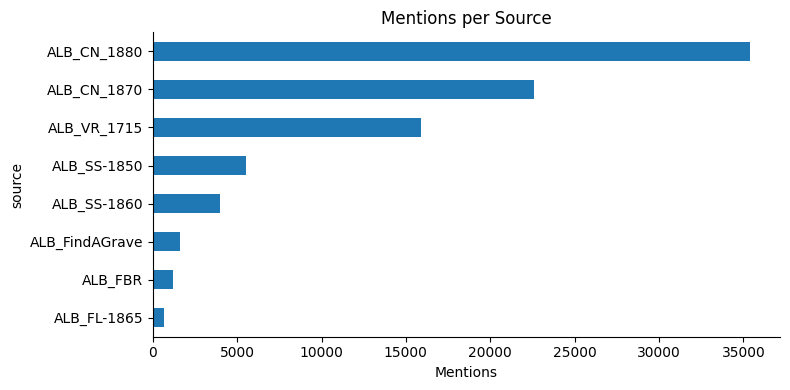

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
source_counts.sort_values().plot.barh(ax=ax)
ax.set_xlabel('Mentions')
ax.set_title('Mentions per Source')
sns.despine()
plt.tight_layout()
plt.show()

## Pre/Post 1870 Split

era
post-1870    67672
pre-1870     19153
Name: count, dtype: int64



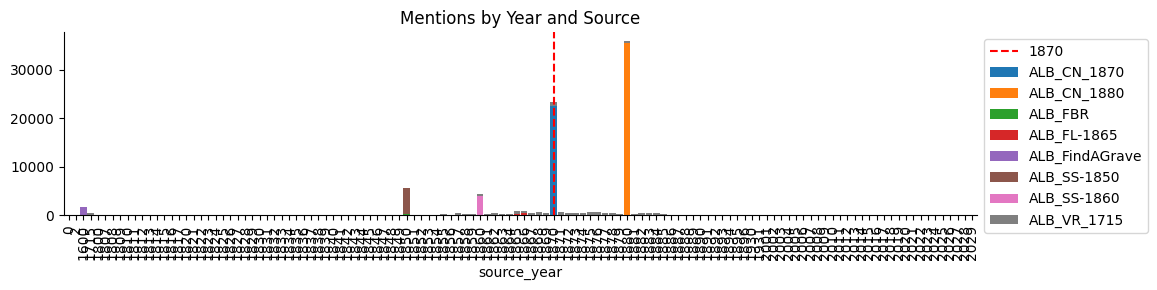

In [6]:
MENTION['era'] = MENTION['source_year'].apply(
    lambda y: 'pre-1870' if pd.notna(y) and y < 1870 else ('post-1870' if pd.notna(y) and y >= 1870 else 'unknown')
)
print(MENTION['era'].value_counts())
print()

fig, ax = plt.subplots(figsize=(10, 3))
MENTION.groupby(['source_year', 'source']).size().unstack().plot.bar(stacked=True, ax=ax, width=0.9)
ax.axvline(x=list(MENTION['source_year'].sort_values().unique()).index(1870), color='red', linestyle='--', label='1870')
ax.set_title('Mentions by Year and Source')
ax.legend(bbox_to_anchor=(1, 1))
sns.despine()
plt.tight_layout()
plt.show()

## Field Coverage by Source

What fraction of records in each source have a non-null value for each field?
This directly determines which fields can be used for blocking and comparison.

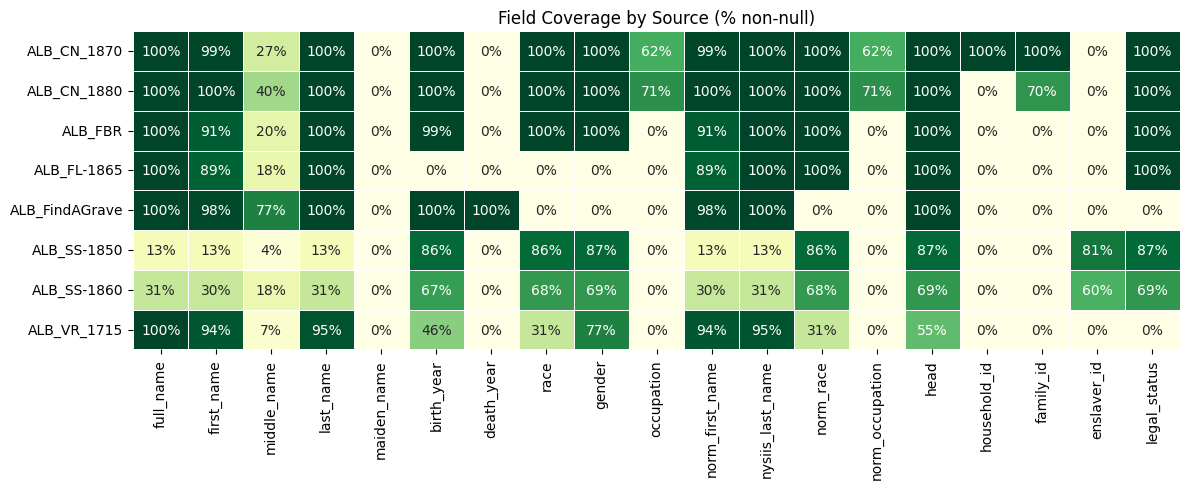

In [7]:
linkage_cols = [
    'full_name', 'first_name', 'middle_name', 'last_name', 'maiden_name',
    'birth_year', 'death_year', 'race', 'gender', 'occupation',
    'norm_first_name', 'nysiis_last_name', 'norm_race', 'norm_occupation',
    'head', 'household_id', 'family_id', 'enslaver_id', 'legal_status'
]

coverage = MENTION.groupby('source')[linkage_cols].apply(
    lambda g: g.notna().mean()
)

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(coverage, annot=True, fmt='.0%', cmap='YlGn', vmin=0, vmax=1,
            linewidths=0.5, ax=ax, cbar=False)
ax.set_title('Field Coverage by Source (% non-null)')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

## Name Quality by Source

For record linkage, names are the primary signal. Check how many records
have usable name fields per source.

In [8]:
name_cols = ['first_name', 'last_name', 'norm_first_name', 'nysiis_last_name', 'full_name']

for source, grp in MENTION.groupby('source'):
    print(f"\n=== {source} (n={len(grp):,}) ===")
    for col in name_cols:
        n_valid = grp[col].notna().sum()
        n_unique = grp[col].nunique()
        print(f"  {col:<22} {n_valid:>6,} non-null  {n_unique:>6,} unique")


=== ALB_CN_1870 (n=22,587) ===
  first_name             22,346 non-null   2,342 unique
  last_name              22,585 non-null   2,081 unique
  norm_first_name        22,344 non-null   2,237 unique
  nysiis_last_name       22,585 non-null   1,500 unique
  full_name              22,585 non-null  19,447 unique

=== ALB_CN_1880 (n=35,404) ===
  first_name             35,276 non-null   3,257 unique
  last_name              35,403 non-null   3,625 unique
  norm_first_name        35,276 non-null   3,128 unique
  nysiis_last_name       35,402 non-null   2,322 unique
  full_name              35,403 non-null  32,519 unique

=== ALB_FBR (n=1,193) ===
  first_name              1,086 non-null     284 unique
  last_name               1,193 non-null     266 unique
  norm_first_name         1,086 non-null     268 unique
  nysiis_last_name        1,193 non-null     235 unique
  full_name               1,193 non-null     947 unique

=== ALB_FL-1865 (n=640) ===
  first_name                572 non-null

## Birth Year Distribution by Source

Birth year is a key comparison field. Check availability and plausible ranges.

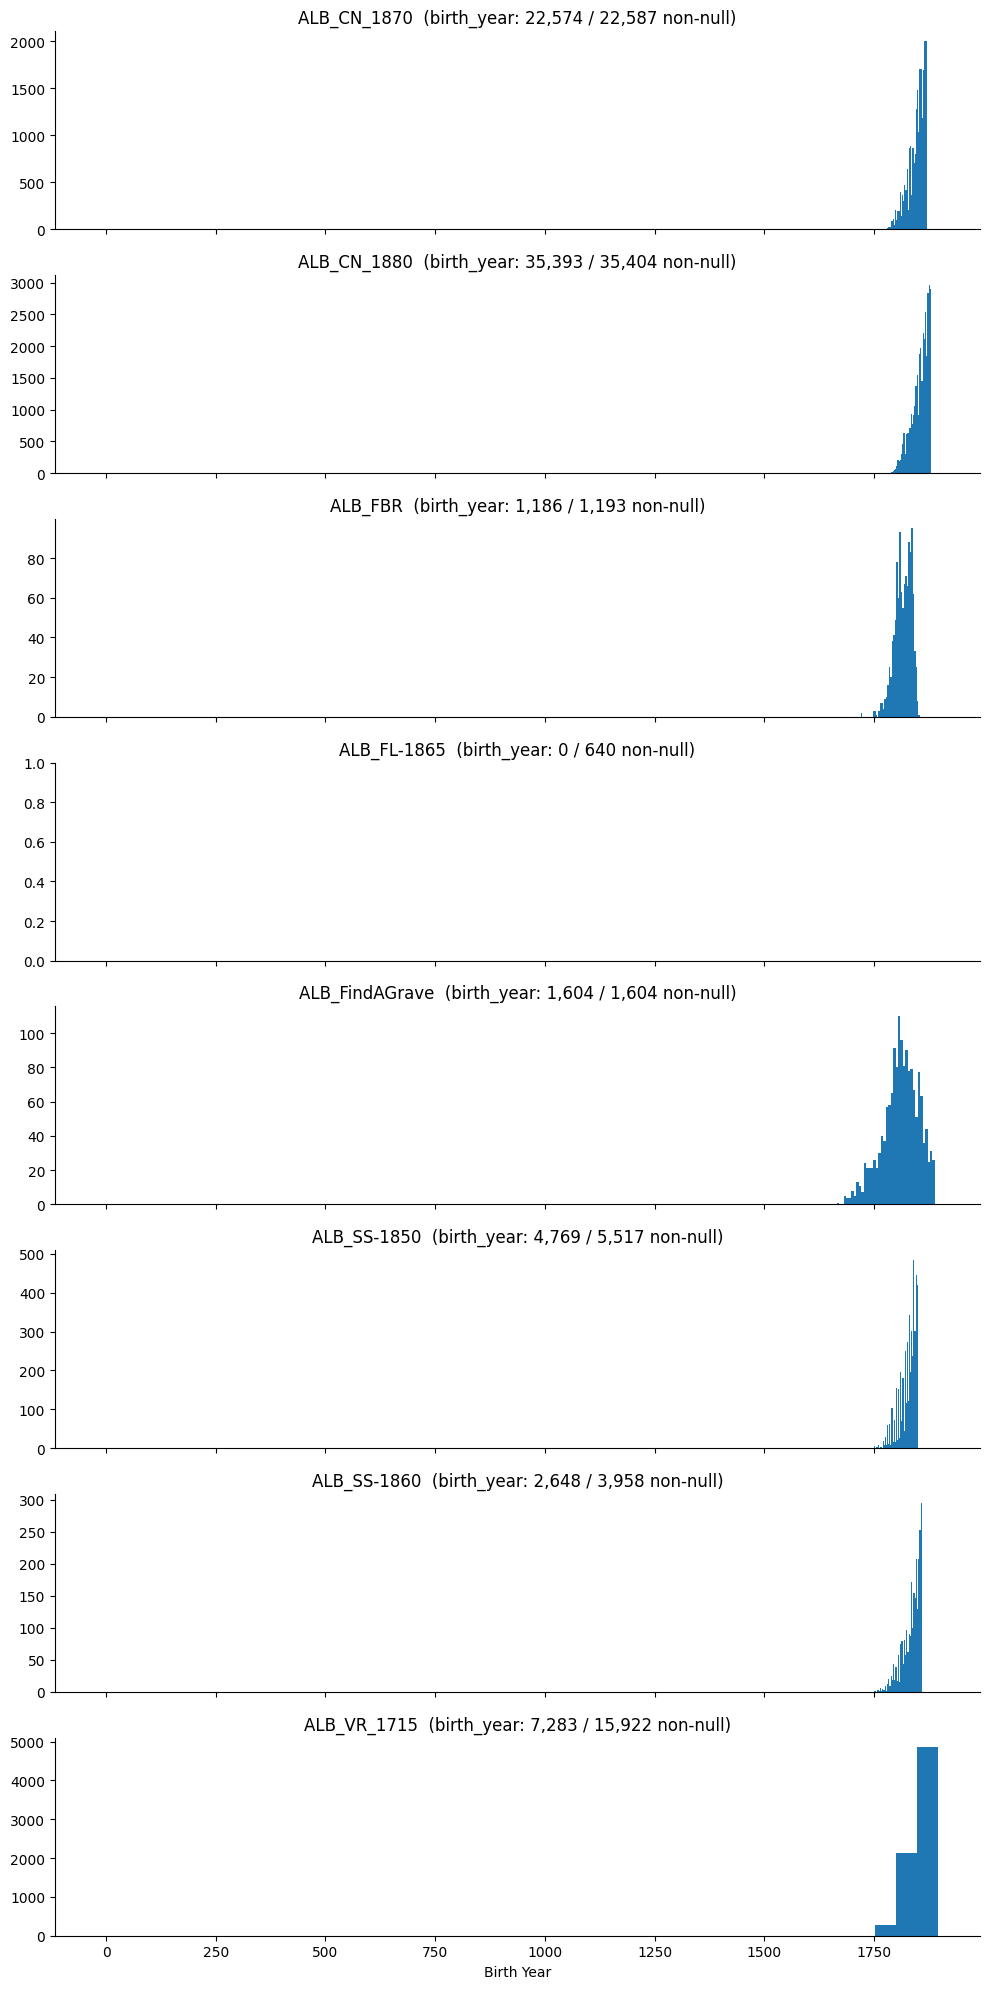

In [9]:
fig, axes = plt.subplots(len(MENTION['source'].unique()), 1,
                          figsize=(10, 2.5 * MENTION['source'].nunique()),
                          sharex=True)

for ax, (source, grp) in zip(axes, MENTION.groupby('source')):
    by = grp['birth_year'].dropna()
    if len(by) > 0:
        by.plot.hist(bins=40, ax=ax)
    ax.set_title(f"{source}  (birth_year: {len(by):,} / {len(grp):,} non-null)")
    ax.set_ylabel('')

axes[-1].set_xlabel('Birth Year')
sns.despine()
plt.tight_layout()
plt.show()

## Household and Family Coverage

`household_id` and `family_id` are strong blocking signals if they are
consistent *within* a source. Check whether they are populated and how
many people share a household on average.

In [10]:
for source, grp in MENTION.groupby('source'):
    hh = grp['household_id'].notna().mean()
    fam = grp['family_id'].notna().mean()
    ens = grp['enslaver_id'].notna().mean()
    hh_size = grp.groupby('household_id').size().mean() if hh > 0 else float('nan')
    print(f"{source:<15}  household: {hh:.0%}  family: {fam:.0%}  enslaver: {ens:.0%}  avg_hh_size: {hh_size:.1f}")

ALB_CN_1870      household: 100%  family: 100%  enslaver: 0%  avg_hh_size: 10.3
ALB_CN_1880      household: 0%  family: 70%  enslaver: 0%  avg_hh_size: nan
ALB_FBR          household: 0%  family: 0%  enslaver: 0%  avg_hh_size: nan
ALB_FL-1865      household: 0%  family: 0%  enslaver: 0%  avg_hh_size: nan
ALB_FindAGrave   household: 0%  family: 0%  enslaver: 0%  avg_hh_size: nan
ALB_SS-1850      household: 0%  family: 0%  enslaver: 81%  avg_hh_size: nan
ALB_SS-1860      household: 0%  family: 0%  enslaver: 60%  avg_hh_size: nan
ALB_VR_1715      household: 0%  family: 0%  enslaver: 0%  avg_hh_size: nan


## Summary: Linkage Strategy Per Source Pair

Based on the above, identify the best blocking and comparison fields
for each pair of sources.

In [11]:
from itertools import combinations

sources_list = sorted(MENTION['source'].unique())
rows = []

for s1, s2 in combinations(sources_list, 2):
    g1 = MENTION[MENTION['source'] == s1]
    g2 = MENTION[MENTION['source'] == s2]
    era1 = 'pre' if g1['source_year'].max() < 1870 else 'post'
    era2 = 'pre' if g2['source_year'].max() < 1870 else 'post'
    has_name = (
        g1['nysiis_last_name'].notna().mean() > 0.5 and
        g2['nysiis_last_name'].notna().mean() > 0.5
    )
    has_birth_year = (
        g1['birth_year'].notna().mean() > 0.3 and
        g2['birth_year'].notna().mean() > 0.3
    )
    has_enslaver = (
        g1['enslaver_id'].notna().mean() > 0.1 or
        g2['enslaver_id'].notna().mean() > 0.1
    )
    rows.append({
        'source_1': s1, 'source_2': s2,
        'pair_type': f"{era1}/{era2}",
        'name_usable': has_name,
        'birth_year_usable': has_birth_year,
        'enslaver_usable': has_enslaver,
        'n_1': len(g1), 'n_2': len(g2)
    })

pd.DataFrame(rows).sort_values('pair_type')

,source_1,source_2,pair_type,name_usable,birth_year_usable,enslaver_usable,n_1,n_2
0,ALB_CN_1870,ALB_CN_1880,post/post,True,True,False,22587,35404
2,ALB_CN_1870,ALB_FL-1865,post/post,True,False,False,22587,640
6,ALB_CN_1870,ALB_VR_1715,post/post,True,True,False,22587,15922
8,ALB_CN_1880,ALB_FL-1865,post/post,True,False,False,35404,640
12,ALB_CN_1880,ALB_VR_1715,post/post,True,True,False,35404,15922
21,ALB_FL-1865,ALB_VR_1715,post/post,True,False,False,640,15922
1,ALB_CN_1870,ALB_FBR,post/pre,True,True,False,22587,1193
3,ALB_CN_1870,ALB_FindAGrave,post/pre,True,True,False,22587,1604
4,ALB_CN_1870,ALB_SS-1850,post/pre,False,True,True,22587,5517
5,ALB_CN_1870,ALB_SS-1860,post/pre,False,True,True,22587,3958
